In [40]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [41]:
df = pd.read_csv("student_performance.csv")

In [42]:
print("\nFirst 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())

# Dataset information
print("\nDataset Information:")
print(df.info())

# Check shape (rows, columns)
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Data types
print("\nData Types:")
print(df.dtypes)

# Unique values in each column
print("\nUnique Values Count:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


First 5 Rows:
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            

In [43]:
# Connect to SQLite Database
conn = sqlite3.connect("student_analytics.db")

# Save DataFrame to SQLite
df.to_sql("students", conn, if_exists="replace", index=False)

# Close connection
conn.close()
print("DataFrame saved to student_analytics.db as 'students' table.")

DataFrame saved to student_analytics.db as 'students' table.


In [44]:
conn = sqlite3.connect("student_analytics.db")
queries = {
    "Average Programming Score":
    """
    SELECT department,
           AVG(programming_score) AS Avg_Programming_Score
    FROM students
    GROUP BY department;
    """,
    "Top 5 Students":
    """
    SELECT name, department, programming_score
    FROM students
    ORDER BY programming_score DESC
    LIMIT 5;
    """,
    "Average Attendance":
    """
    SELECT department,
           AVG(attendance_percentage) AS Avg_Attendance
    FROM students
    GROUP BY department;
    """,
    "Attendance Above 90":
    """
    SELECT name, department, attendance_percentage
    FROM students
    WHERE attendance_percentage > 90;
    """,
    "Department Student Count":
    """
    SELECT department,
           COUNT(*) AS Total_Students
    FROM students
    GROUP BY department;
    """
}

for title, query in queries.items():
    print(f"\n{'='*50}")
    print(title)
    print('='*50)
    print(pd.read_sql(query, conn))

conn.close()


Average Programming Score
         department  Avg_Programming_Score
0             Civil              40.600000
1  Computer Science              89.230769
2       Electronics              61.500000
3        Mechanical              49.333333

Top 5 Students
             name        department  programming_score
0      Ananya Das  Computer Science                 97
1     Tanvi Mehta  Computer Science                 96
2      Arjun Nair  Computer Science                 95
3  Akanksha Yadav  Computer Science                 94
4     Divya Singh  Computer Science                 93

Average Attendance
         department  Avg_Attendance
0             Civil       74.600000
1  Computer Science       90.692308
2       Electronics       80.333333
3        Mechanical       83.500000

Attendance Above 90
             name        department  attendance_percentage
0    Aarav Sharma  Computer Science                     92
1     Sneha Reddy        Mechanical                     95
2     Divya Si

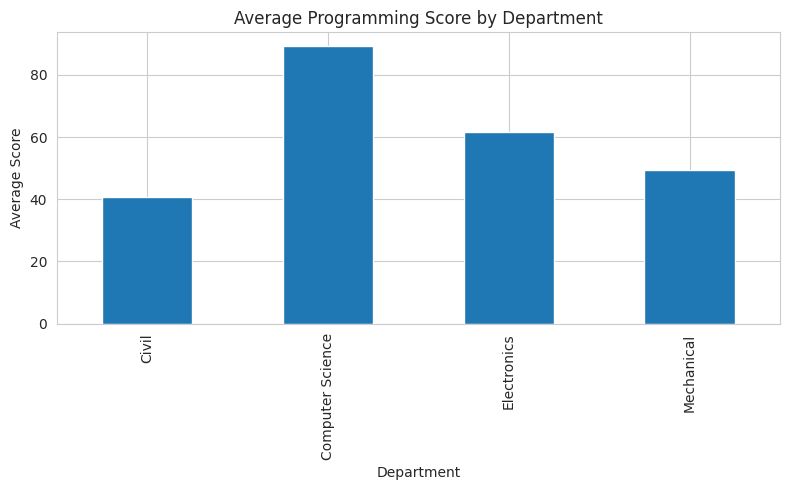

In [45]:
sns.set_style("whitegrid")
# Chart 1: Department Average Programming Score
plt.figure(figsize=(8,5))

dept_avg = df.groupby("department")["programming_score"].mean()

dept_avg.plot(kind="bar")

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()


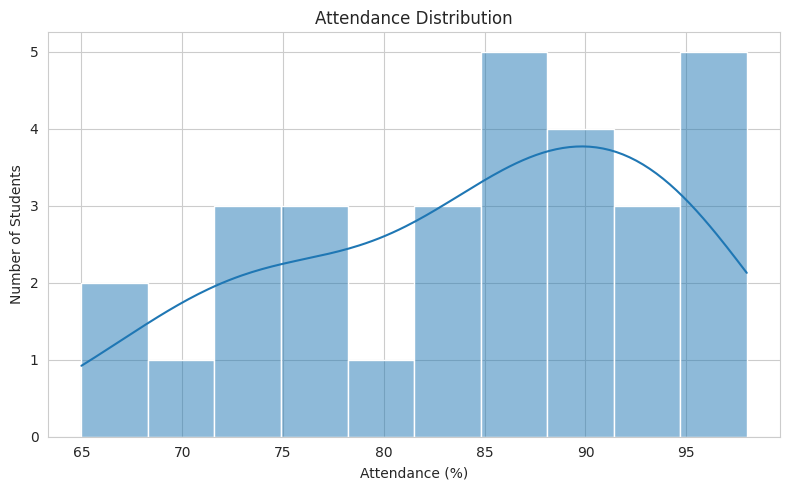

In [46]:
#2: Attendance Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["attendance_percentage"], bins=10, kde=True)
plt.title("Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


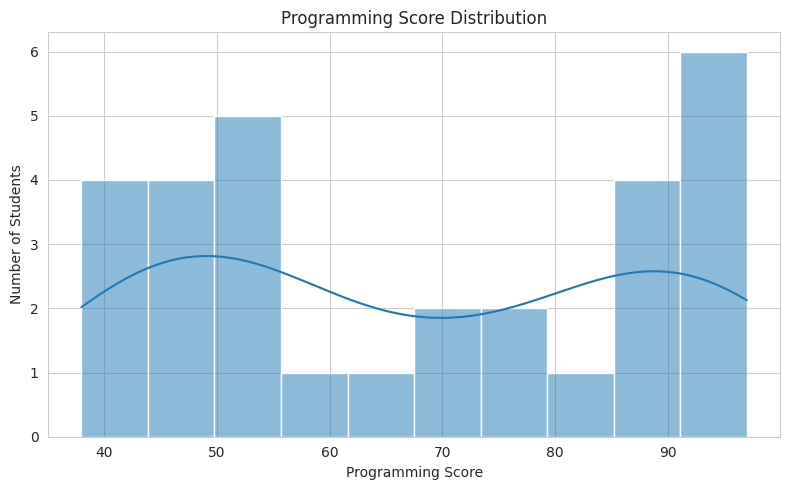

In [47]:
#3:Programming Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["programming_score"], bins=10, kde=True)
plt.title("Programming Score Distribution")
plt.xlabel("Programming Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

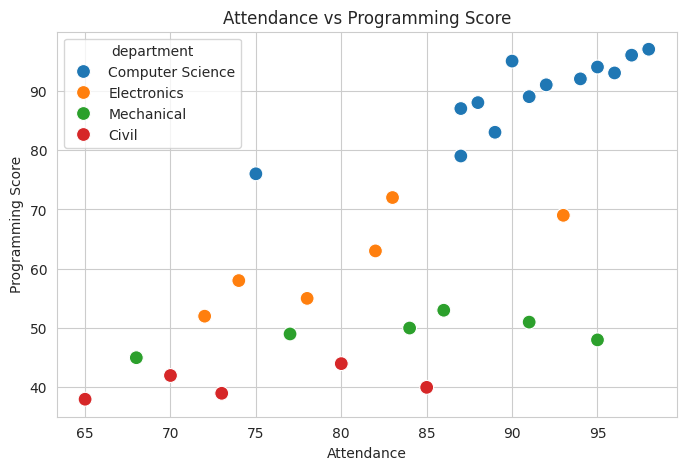

In [48]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="programming_score",
    hue="department",
    s=100
)
plt.title("Attendance vs Programming Score")
plt.xlabel("Attendance")
plt.ylabel("Programming Score")
plt.show()

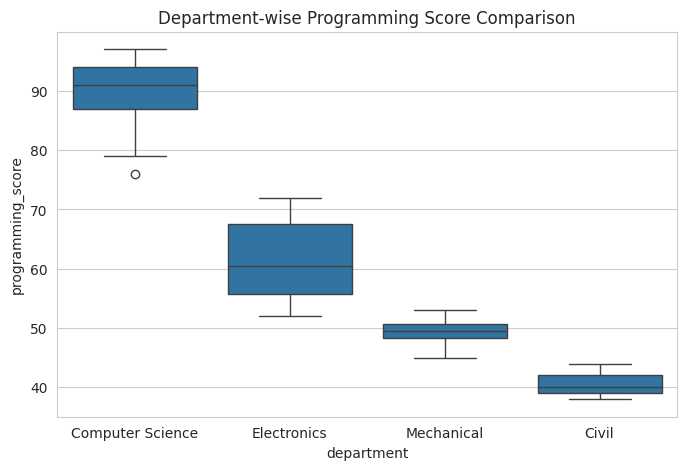

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="department",
    y="programming_score",
    data=df
)
plt.title("Department-wise Programming Score Comparison")
plt.show()

In [50]:
conn = sqlite3.connect("student_analytics.db")
df = pd.read_sql("SELECT * FROM students", conn)
conn.close()

# Convert categorical columns to numerical values using one-hot encoding
df = pd.get_dummies(df, columns=["department", "gender", "city"], drop_first=True)

# Features and Target
X = df.drop(["programming_score", "name", "student_id"], axis=1)
y = df["programming_score"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
# Example Prediction
sample = X_test.iloc[[0]]
prediction = model.predict(sample)

print("\nPredicted Programming Score:", prediction[0])
print("Actual Score:", y_test.iloc[0])

R2 Score: 0.962818795019264
MAE: 3.591666666666665

Predicted Programming Score: 46.23
Actual Score: 39


In [51]:
print("\n" + "="*60)
print("STUDENT ANALYTICS REPORT")
print("="*60)

print(f"Total Students: {len(df)}")

avg_prog = df["programming_score"].mean()
avg_att = df["attendance_percentage"].mean()

print(f"Average Programming Score: {avg_prog:.2f}")
print(f"Average Attendance: {avg_att:.2f}%")

top_score = df["programming_score"].max()
print(f"Highest Programming Score: {top_score}")

print("\nKey Insights:")
print("1. Students with higher attendance generally achieve better programming scores.")
print("2. Random Forest successfully predicts programming performance.")
print("3. Departments can be compared using visualization dashboards.")
print("4. Attendance monitoring may improve academic outcomes.")
print("5. Analytics helps identify top-performing students and departments.")

print("\nRecommendation:")
print("Increase attendance tracking and provide support to students with low attendance.")


STUDENT ANALYTICS REPORT
Total Students: 30
Average Programming Score: 67.60
Average Attendance: 84.50%
Highest Programming Score: 97

Key Insights:
1. Students with higher attendance generally achieve better programming scores.
2. Random Forest successfully predicts programming performance.
3. Departments can be compared using visualization dashboards.
4. Attendance monitoring may improve academic outcomes.
5. Analytics helps identify top-performing students and departments.

Recommendation:
Increase attendance tracking and provide support to students with low attendance.
